In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Data Loading & Preprocessing

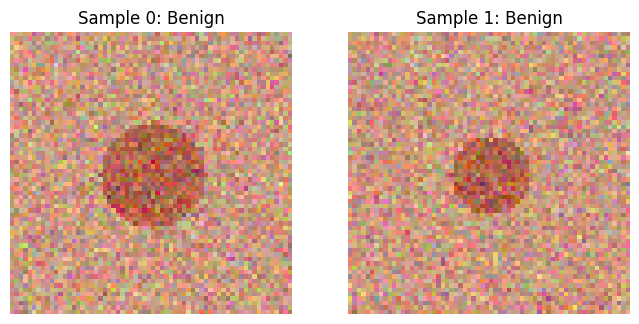

In [31]:
def generate_synthetic_skin_data(n):
    """
    Generates synthetic 'skin lesion' data.
    X: (n, 28, 28) - Grayscale images (simplified for manual CNN)
    y: (n) - Labels 0 (Benign) or 1 (Malignant)
    """
    print(f"Generating {n} samples...")
    X = np.zeros((n, 28, 28)) 
    y = np.zeros(n, dtype=int)

    for i in range(n):
        # 1. Base skin noise
        base_img = np.random.normal(0.5, 0.1, (28, 28))
        
        # 2. Create a lesion mask (random circle)
        y_grid, x_grid = np.ogrid[:28, :28]
        center_y, center_x = np.random.randint(10, 18), np.random.randint(10, 18)
        radius = np.random.randint(4, 9)
        mask = (x_grid - center_x)**2 + (y_grid - center_y)**2 <= radius**2

        # 3. Assign Class
        if np.random.rand() > 0.5:
            # Malignant: Darker, irregular pixel drops
            base_img[mask] -= 0.4
            # Add some random noise inside lesion
            noise = np.random.normal(0, 0.1, (28, 28))
            base_img[mask] += noise[mask]
            y[i] = 1 
        else:
            # Benign: Lighter, smoother
            base_img[mask] -= 0.2
            y[i] = 0
            
        X[i] = base_img

    return X, y
# 2. Visualize the first 2 images
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i in range(2):
    # Transpose from (3, 64, 64) -> (64, 64, 3) for Matplotlib
    img_display = np.transpose(X[i], (1, 2, 0))
    label_text = "Malignant" if y[i, 1] == 1 else "Benign"
    
    axes[i].imshow(img_display)
    axes[i].set_title(f"Sample {i}: {label_text}")
    axes[i].axis('off')

plt.show()

## 2. The Convolution Layer

In [ ]:
class Conv3x3:
    #Convolution Layer using 3x3 filters.
    def __init__(self, num_filters):
        self.num_filters = num_filters
        # Filters shape: (num_filters, 3, 3)
        # Xavier Initialization simplified
        self.filters = np.random.randn(num_filters, 3, 3) / 9 

    def iterate_regions(self, image):
    # Generates all valid 3x3 image regions (valid padding).
        h, w = image.shape
        for i in range(h - 2):
            for j in range(w - 2):
                im_region = image[i:(i + 3), j:(j + 3)]
                yield im_region, i, j

    def forward(self, input):
    #Performs 3x3 convolution where Output decreases size by 2: 28x28 -> 26x26
        self.last_input = input
        h, w = input.shape
        output = np.zeros((h - 2, w - 2, self.num_filters))

        for im_region, i, j in self.iterate_regions(input):
            # Element-wise multiply region * filters, then sum
            output[i, j] = np.sum(im_region * self.filters, axis=(1, 2))

        return output

    def backprop(self, d_L_d_out, learn_rate):
        """
        Calculates gradients for filters and updates them.
        d_L_d_out: Gradient from the next layer (MaxPool).
        """
        d_L_d_filters = np.zeros(self.filters.shape)

        for im_region, i, j in self.iterate_regions(self.last_input):
            for f in range(self.num_filters):
                # Gradient accumulation
                d_L_d_filters[f] += d_L_d_out[i, j, f] * im_region

        # Update filters (Stochastic Gradient Descent)
        self.filters -= learn_rate * d_L_d_filters
        
        # We stop backprop here (first layer), so we don't return gradient for input.
        return None

# 3. The Max Pooling Layer

In [ ]:
class MaxPool2:
    """
    Max Pooling layer 2x2.
    """
    def iterate_regions(self, image):
        h, w, _ = image.shape
        new_h = h // 2
        new_w = w // 2
        
        for i in range(new_h):
            for j in range(new_w):
                im_region = image[(i * 2):(i * 2 + 2), (j * 2):(j * 2 + 2)]
                yield im_region, i, j

    def forward(self, input):
    # Downsamples input by 2. 26x26x8 -> 13x13x8
        self.last_input = input
        h, w, num_filters = input.shape
        output = np.zeros((h // 2, w // 2, num_filters))

        for im_region, i, j in self.iterate_regions(input):
            output[i, j] = np.amax(im_region, axis=(0, 1))

        return output

    def backprop(self, d_L_d_out):
    #Passes gradient only to the pixel that was the 'max'.
        d_L_d_input = np.zeros(self.last_input.shape)

        for im_region, i, j in self.iterate_regions(self.last_input):
            h, w, f = im_region.shape
            amax = np.amax(im_region, axis=(0, 1))

            for i2 in range(h):
                for j2 in range(w):
                    for f2 in range(f):
                        # If this pixel was the max, it gets the gradient
                        if im_region[i2, j2, f2] == amax[f2]:
                            d_L_d_input[i * 2 + i2, j * 2 + j2, f2] = d_L_d_out[i, j, f2]

        return d_L_d_input

# 4. Fully Connected (Softmax) Layer

In [ ]:
class Softmax:
    #Fully Connected Layer (Dense) + Softmax Activation.

    def __init__(self, input_len, nodes):
        # He Initialization
        self.weights = np.random.randn(input_len, nodes) / input_len
        self.biases = np.zeros(nodes)

    def forward(self, input):
       # Flattens input and applies Matrix Mul + Softmax.
        self.last_input_shape = input.shape
        
        # Flatten (13, 13, 8) -> (1352)
        input = input.flatten()
        self.last_input = input

        # Linear pass: z = Wx + b
        totals = np.dot(input, self.weights) + self.biases
        self.last_totals = totals
        
        # Softmax: e^x / sum(e^x)
        # Subtract max for numerical stability
        exp_vals = np.exp(totals - np.max(totals)) 
        return exp_vals / np.sum(exp_vals, axis=0)

    def backprop(self, d_L_d_out, learn_rate):
        """
        Gradient Descent for Weights and Biases.
        Note: d_L_d_out here is actually (Predicted - True Label) if using Cross Entropy.
        """
        # We know d_L_d_out is the gradient of Loss wrt Totals (z)
        # This simplifies the math significantly.
        # dL/dz = prediction - target (where target is 1 for correct class, 0 otherwise)
        
        for i, gradient in enumerate(d_L_d_out):
            if gradient == 0: continue

            # Gradient of Loss w.r.t. Totals (pre-activation)
            d_L_d_t = d_L_d_out 

            # Gradient of Loss w.r.t. Weights: input * d_L_d_t
            d_L_d_w = self.last_input[np.newaxis].T @ d_L_d_t[np.newaxis]
            
            # Gradient of Loss w.r.t. Biases: d_L_d_t
            d_L_d_b = d_L_d_t
            
            # Gradient of Loss w.r.t. Inputs (to pass to prev layer)
            d_L_d_inputs = self.weights @ d_L_d_t

            # Update weights and biases
            self.weights -= learn_rate * d_L_d_w
            self.biases -= learn_rate * d_L_d_b
            
            # Reshape d_L_d_inputs back to 3D for MaxPool layer
            return d_L_d_inputs.reshape(self.last_input_shape)

# 5. Training Loop

In [38]:
train_images, train_labels = generate_synthetic_skin_data(500)
test_images, test_labels = generate_synthetic_skin_data(20)

# Define Network
conv = Conv3x3(8)                  # 28x28x1 -> 26x26x8
pool = MaxPool2()                  # 26x26x8 -> 13x13x8
softmax = Softmax(13 * 13 * 8, 2)  # 1352 -> 2

# Helper: Cross Entropy Loss
def forward_pass(image, label):
    # Transform image from (28, 28) to (28, 28) - just normalization if needed
    out = conv.forward((image / 255) - 0.5) 
    out = pool.forward(out)
    out = softmax.forward(out)
    
    # Calculate Loss: -ln(p_correct)
    loss = -np.log(out[label])
    # Calculate Accuracy: 1 if correct, 0 if wrong
    acc = 1 if np.argmax(out) == label else 0
    
    return out, loss, acc

def train(im, label, lr=0.005):
    # 1. Forward
    out, loss, acc = forward_pass(im, label)
    
    # 2. Calculate Initial Gradient
    gradient = np.zeros(2)
    gradient[label] = -1 / out[label] # Derivative of Cross Entropy
    
    # Combine Softmax derivative * CE derivative -> Pred - OneHot(y)
    gradient = out
    gradient[label] -= 1 # This becomes (p - y)
    
    # 3. Backward
    grad_back = softmax.backprop(gradient, lr)
    grad_back = pool.backprop(grad_back)
    grad_back = conv.backprop(grad_back, lr)
    
    return loss, acc

print("\n--- Starting Training")

loss_history = []
acc_history = []

# Train for 3 Epochs (Short for demo speed)
for epoch in range(3):
    print(f'--- Epoch {epoch + 1} ---')
    
    # Shuffle data
    permutation = np.random.permutation(len(train_images))
    train_images = train_images[permutation]
    train_labels = train_labels[permutation]
    
    loss_sum = 0
    acc_sum = 0
    
    for i, (im, label) in enumerate(zip(train_images, train_labels)):
        if i % 100 == 0 and i > 0:
            print(f'   Step {i}: Avg Loss {loss_sum/100:.3f} | Avg Acc {acc_sum/100:.2f}')
            loss_history.append(loss_sum/100)
            acc_history.append(acc_sum/100)
            loss_sum = 0
            acc_sum = 0
            
        l, a = train(im, label)
        loss_sum += l
        acc_sum += a

Generating 500 samples...
Generating 20 samples...

--- Starting Training
--- Epoch 1 ---
   Step 100: Avg Loss 0.698 | Avg Acc 0.57
   Step 200: Avg Loss 0.688 | Avg Acc 0.58
   Step 300: Avg Loss 0.703 | Avg Acc 0.44
   Step 400: Avg Loss 0.700 | Avg Acc 0.42
--- Epoch 2 ---
   Step 100: Avg Loss 0.697 | Avg Acc 0.48
   Step 200: Avg Loss 0.695 | Avg Acc 0.50
   Step 300: Avg Loss 0.696 | Avg Acc 0.37
   Step 400: Avg Loss 0.695 | Avg Acc 0.44
--- Epoch 3 ---
   Step 100: Avg Loss 0.695 | Avg Acc 0.44
   Step 200: Avg Loss 0.695 | Avg Acc 0.49
   Step 300: Avg Loss 0.694 | Avg Acc 0.48
   Step 400: Avg Loss 0.695 | Avg Acc 0.40


# 6. Visualisation

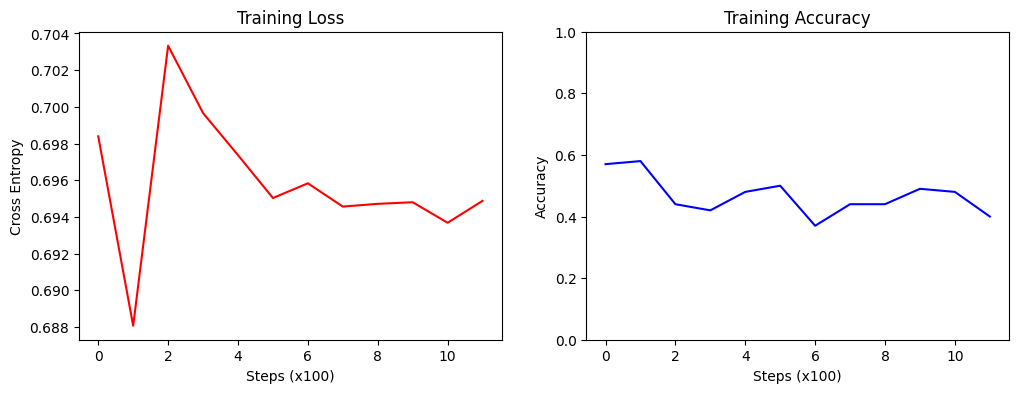

In [39]:

# A. Plot Training History
df_hist = pd.DataFrame({'Loss': loss_history, 'Accuracy': acc_history})

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df_hist['Loss'], label='Loss', color='red')
plt.title('Training Loss')
plt.xlabel('Steps (x100)')
plt.ylabel('Cross Entropy')

plt.subplot(1, 2, 2)
plt.plot(df_hist['Accuracy'], label='Accuracy', color='blue')
plt.title('Training Accuracy')
plt.xlabel('Steps (x100)')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# 7. Evaluation


Test Set Predictions


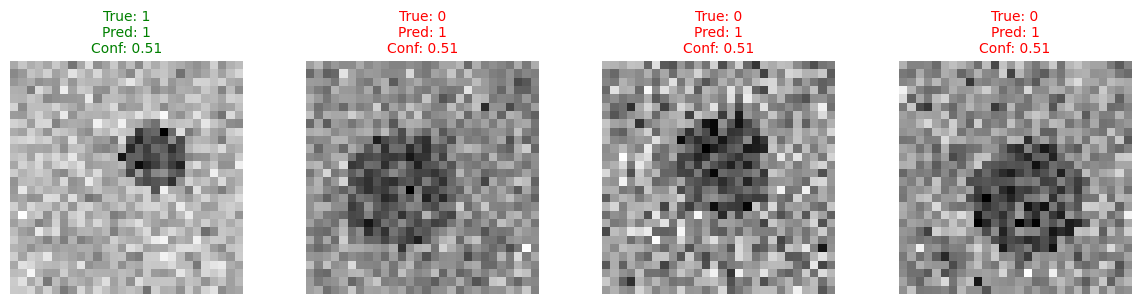

In [41]:
print("\nTest Set Predictions")
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    im = test_images[i]
    lbl = test_labels[i]
    
    # Get prediction
    # Normalize input like in training
    out = conv.forward((im / 255) - 0.5) 
    out = pool.forward(out)
    pred_probs = softmax.forward(out)
    pred_label = np.argmax(pred_probs)
    
    # Visualization
    axes[i].imshow(im, cmap='gray')
    title_text = f"True: {lbl}\nPred: {pred_label}\nConf: {pred_probs[pred_label]:.2f}"
    
    # Color code title: Green if correct, Red if wrong
    color = 'green' if lbl == pred_label else 'red'
    axes[i].set_title(title_text, color=color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()